# scMRDR aligned UMAP visualization

This notebook visualizes the **shared aligned latent representation** learned by scMRDR after training.

The aligned representation is read from:

```python
adata.obsm["latent_shared"]
```

inside each:

```text
training_adata_post.h5ad
```

For **PBMC**, the original dataset does not contain the cell-type labels needed for the biological UMAP panel. This notebook therefore loads the external Azimuth annotation file:

```text
/data5/zhangye/scMRDR/input/PBMC/raw_input/pbmc_azimuth_annotations.csv
```

and maps the labels back to cells by `cell_id`.

The notebook supports:

- PBMC ATAC–RNA
- BMMC ATAC–RNA
- BMMC RNA–Protein
- automatic discovery of `single_XXX` ratio folders
- UMAP colored by modality
- UMAP colored by cell type
- PBMC Azimuth label levels L1 / L2 / L3
- interactive experiment / ratio / label-level / UMAP controls
- PNG/PDF export
- UMAP coordinate export

The modality-colored and cell-type-colored panels use **exactly the same UMAP coordinates**.


## 1. Imports

`ipywidgets` is optional. The normal plotting workflow works without it; only the interactive explorer requires it.

```bash
pip install ipywidgets
```


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets is not installed. Interactive controls will be skipped.")

sc.settings.verbosity = 2

print("scanpy:", sc.__version__)
print("ipywidgets available:", HAS_WIDGETS)


ipywidgets is not installed. Interactive controls will be skipped.
scanpy: 1.10.3
ipywidgets available: False


## 2. Project and experiment settings

For PBMC, `annotation_csv` points to the separately generated Azimuth annotation table.

`predicted.celltype.l2` is used by default because it gives biologically interpretable intermediate-resolution labels. You can switch to L1 or L3 later.


In [2]:
# ============================================================
# Project settings
# ============================================================

PROJECT_ROOT = Path("/data5/zhangye/scMRDR")

PBMC_ANNOTATION_PATH = (
    PROJECT_ROOT
    / "input/PBMC/raw_input/pbmc_azimuth_annotations.csv"
)

EXPERIMENTS = {
    "PBMC ATAC-RNA": {
        "out_root": PROJECT_ROOT / "output/PBMC/scMRDR_results",
        "expected_modalities": ["rna", "atac"],
        "annotation_csv": PBMC_ANNOTATION_PATH,
        "annotation_id_col": "cell_id",
        "annotation_columns": [
            "predicted.celltype.l1",
            "predicted.celltype.l2",
            "predicted.celltype.l3",
        ],
        "default_celltype_key": "predicted.celltype.l2",
        "annotation_required": True,
    },
    "BMMC ATAC-RNA": {
        "out_root": PROJECT_ROOT / "output/BMMC/scMRDR_results_atac_to_rna",
        "expected_modalities": ["rna", "atac"],
        "annotation_csv": None,
        "default_celltype_key": None,
        "annotation_required": False,
    },
    "BMMC RNA-Protein": {
        "out_root": PROJECT_ROOT / "output/BMMC/scMRDR_results_rna_to_protein",
        "expected_modalities": ["rna", "protein"],
        "annotation_csv": None,
        "default_celltype_key": None,
        "annotation_required": False,
    },
}

POST_H5AD_NAME = "training_adata_post.h5ad"
LATENT_KEY = "latent_shared"
MODALITY_KEY = "modality"

CELLTYPE_CANDIDATES = [
    "cell_type",
    "celltype",
    "cell_types",
    "CellType",
    "cell_type_l1",
    "cell_type_l2",
    "predicted.celltype.l1",
    "predicted.celltype.l2",
    "predicted.celltype.l3",
    "annotation",
    "label",
    "labels",
]

# UMAP defaults
N_NEIGHBORS = 30
MIN_DIST = 0.35
RANDOM_STATE = 1234

# Set an integer (e.g. 50000) for very large datasets.
MAX_CELLS = None

# Plot defaults
POINT_SIZE = 5.0
POINT_ALPHA = 0.75
DPI = 300

print("Project root:", PROJECT_ROOT)
print("PBMC annotation:", PBMC_ANNOTATION_PATH)

for name, cfg in EXPERIMENTS.items():
    print(f"{name:18s} -> {cfg['out_root']}")


Project root: /data5/zhangye/scMRDR
PBMC annotation: /data5/zhangye/scMRDR/input/PBMC/raw_input/pbmc_azimuth_annotations.csv
PBMC ATAC-RNA      -> /data5/zhangye/scMRDR/output/PBMC/scMRDR_results
BMMC ATAC-RNA      -> /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna
BMMC RNA-Protein   -> /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_rna_to_protein


## 3. Inspect the PBMC Azimuth annotation table

The uploaded annotation table contains:

- `cell_id`
- `predicted.celltype.l1`
- `predicted.celltype.l2`
- `predicted.celltype.l3`
- confidence scores for each level

This diagnostic cell is useful for confirming that the server is reading the expected annotation file.


In [3]:
if PBMC_ANNOTATION_PATH.exists():
    pbmc_ann_preview = pd.read_csv(PBMC_ANNOTATION_PATH)

    print("Annotation shape:", pbmc_ann_preview.shape)
    print("Columns:")
    print(list(pbmc_ann_preview.columns))
    print()

    if "cell_id" in pbmc_ann_preview.columns:
        print("Unique cell IDs:", pbmc_ann_preview["cell_id"].nunique())
        print("Duplicated cell IDs:", pbmc_ann_preview["cell_id"].duplicated().sum())

    display(
        pbmc_ann_preview[
            [
                c for c in [
                    "cell_id",
                    "predicted.celltype.l1",
                    "predicted.celltype.l2",
                    "predicted.celltype.l3",
                ]
                if c in pbmc_ann_preview.columns
            ]
        ].head()
    )

    for key in [
        "predicted.celltype.l1",
        "predicted.celltype.l2",
        "predicted.celltype.l3",
    ]:
        if key in pbmc_ann_preview.columns:
            print(f"\n{key}: {pbmc_ann_preview[key].nunique()} categories")
            display(pbmc_ann_preview[key].value_counts(dropna=False).to_frame("n_cells"))
else:
    print("PBMC annotation file not found:")
    print(PBMC_ANNOTATION_PATH)


Annotation shape: (11909, 7)
Columns:
['cell_id', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3']

Unique cell IDs: 11909
Duplicated cell IDs: 0


,cell_id,predicted.celltype.l1,predicted.celltype.l2,predicted.celltype.l3
0,AAACAGCCAAGGAATC-1,other,Eryth,Eryth
1,AAACAGCCAATCCCTT-1,other,Eryth,Eryth
2,AAACAGCCAATGCGCT-1,CD4 T,CD4 Naive,CD4 Naive
3,AAACAGCCACACTAAT-1,CD8 T,CD8 Naive,CD8 Naive
4,AAACAGCCACCAACCG-1,CD8 T,CD8 Naive,CD8 Naive



predicted.celltype.l1: 8 categories


,n_cells
predicted.celltype.l1,
other,8549
CD4 T,1742
Mono,629
CD8 T,415
B,322
DC,135
NK,90
other T,27



predicted.celltype.l2: 24 categories


,n_cells
predicted.celltype.l2,
Eryth,8930
CD4 TCM,689
CD14 Mono,553
Treg,455
CD8 Naive,324
CD4 Naive,152
B intermediate,144
CD8 TEM,140
pDC,95



predicted.celltype.l3: 36 categories


,n_cells
predicted.celltype.l3,
Eryth,9242
CD4 TCM_1,563
CD14 Mono,556
CD8 Naive,283
CD4 Naive,174
Treg Memory,159
CD8 TEM_2,105
B intermediate kappa,102
pDC,96


## 4. Data loading and annotation utilities

### How PBMC cell types are restored

The training output contains the latent embeddings and modality labels, but PBMC cell types are stored separately in the Azimuth CSV.

The notebook therefore:

1. reads `training_adata_post.h5ad`;
2. reads `pbmc_azimuth_annotations.csv`;
3. matches each AnnData observation to `cell_id`;
4. adds Azimuth L1/L2/L3 labels to `adata.obs`;
5. computes UMAP from `latent_shared`.

The matcher first tries the exact cell ID. It also recognizes standard 10x barcodes such as `AAAC...-1` inside longer observation names, which makes it robust to common prefixes/suffixes introduced during concatenation.


In [4]:
_ANNOTATION_CACHE = {}


def discover_ratios(out_root: Path) -> list[str]:
    """Find ratio folders that contain training_adata_post.h5ad."""
    out_root = Path(out_root)
    if not out_root.exists():
        return []

    ratios = []
    for d in sorted(out_root.glob("single_*")):
        if d.is_dir() and (d / POST_H5AD_NAME).exists():
            ratios.append(d.name)
    return ratios


def canonicalize_cell_id(value: object) -> str:
    """
    Recover a standard 10x barcode when possible.

    Examples:
      AAACAGCCAAGGAATC-1            -> AAACAGCCAAGGAATC-1
      rna__AAACAGCCAAGGAATC-1      -> AAACAGCCAAGGAATC-1
      AAACAGCCAAGGAATC-1__atac     -> AAACAGCCAAGGAATC-1

    For non-10x IDs, the original string is returned unchanged.
    """
    text = str(value)

    # Typical 10x barcode: DNA barcode followed by "-1", "-2", ...
    match = re.search(r"([ACGTN]{12,}-\d+)", text)
    if match:
        return match.group(1)

    return text


def load_external_annotation(cfg: dict) -> pd.DataFrame | None:
    """Load and cache an experiment-specific annotation table."""
    path = cfg.get("annotation_csv")

    if path is None:
        return None

    path = Path(path)

    if not path.exists():
        if cfg.get("annotation_required", False):
            raise FileNotFoundError(
                "Required external annotation file was not found:\n"
                f"{path}"
            )
        warnings.warn(f"Annotation file not found: {path}")
        return None

    cache_key = str(path.resolve())
    if cache_key in _ANNOTATION_CACHE:
        return _ANNOTATION_CACHE[cache_key]

    ann = pd.read_csv(path)

    id_col = cfg.get("annotation_id_col", "cell_id")
    if id_col not in ann.columns:
        raise KeyError(
            f"Annotation ID column {id_col!r} was not found in {path}. "
            f"Available columns: {list(ann.columns)}"
        )

    annotation_columns = cfg.get("annotation_columns", [])
    missing_columns = [c for c in annotation_columns if c not in ann.columns]
    if missing_columns:
        raise KeyError(
            f"Missing annotation columns in {path}: {missing_columns}"
        )

    ann = ann.copy()
    ann["_canonical_cell_id"] = ann[id_col].map(canonicalize_cell_id)

    duplicated = ann["_canonical_cell_id"].duplicated(keep=False)
    if duplicated.any():
        examples = (
            ann.loc[duplicated, [id_col, "_canonical_cell_id"]]
            .head(10)
            .to_dict("records")
        )
        raise ValueError(
            "The annotation file contains duplicated canonical cell IDs. "
            f"Examples: {examples}"
        )

    ann = ann.set_index("_canonical_cell_id", drop=False)
    _ANNOTATION_CACHE[cache_key] = ann
    return ann


def attach_external_annotation(
    obs: pd.DataFrame,
    cfg: dict,
) -> tuple[pd.DataFrame, dict]:
    """
    Attach external annotation columns to obs by cell ID.

    Returns
    -------
    obs_annotated
        Copy of obs with annotation columns added.
    report
        Matching statistics.
    """
    obs = obs.copy()
    ann = load_external_annotation(cfg)

    if ann is None:
        return obs, {
            "used_external_annotation": False,
            "matched_rows": 0,
            "total_rows": len(obs),
            "match_rate": np.nan,
        }

    annotation_columns = cfg.get("annotation_columns", [])
    canonical_ids = pd.Series(
        [canonicalize_cell_id(x) for x in obs.index.astype(str)],
        index=np.arange(len(obs)),
        dtype="object",
    )

    obs["_annotation_cell_id"] = canonical_ids.to_numpy()

    for col in annotation_columns:
        mapped = canonical_ids.map(ann[col])
        # Assign by position, not index alignment, because AnnData may contain
        # duplicated cell IDs across modalities.
        obs[col] = mapped.to_numpy()

    default_key = cfg.get("default_celltype_key")
    if default_key and default_key in obs.columns:
        matched_mask = obs[default_key].notna().to_numpy()
    elif annotation_columns:
        matched_mask = obs[annotation_columns[0]].notna().to_numpy()
    else:
        matched_mask = np.zeros(len(obs), dtype=bool)

    obs["_annotation_matched"] = matched_mask

    matched_unique = pd.Index(
        obs.loc[matched_mask, "_annotation_cell_id"].astype(str)
    ).nunique()
    total_unique = pd.Index(obs["_annotation_cell_id"].astype(str)).nunique()

    report = {
        "used_external_annotation": True,
        "matched_rows": int(matched_mask.sum()),
        "total_rows": int(len(obs)),
        "match_rate": float(matched_mask.mean()) if len(obs) else np.nan,
        "matched_unique_cells": int(matched_unique),
        "total_unique_cells": int(total_unique),
    }

    return obs, report


def resolve_celltype_key(
    obs: pd.DataFrame,
    cfg: dict,
    requested_key: str | None = None,
) -> str | None:
    """Resolve the cell-type column to use for plotting."""
    if requested_key is not None:
        if requested_key not in obs.columns:
            raise KeyError(
                f"Requested cell-type key {requested_key!r} is unavailable. "
                f"Available obs columns include: {list(obs.columns)}"
            )
        return requested_key

    default_key = cfg.get("default_celltype_key")
    if default_key is not None and default_key in obs.columns:
        return default_key

    for key in CELLTYPE_CANDIDATES:
        if key in obs.columns:
            return key

    return None


def pretty_modality(x: str) -> str:
    x = str(x).strip().lower()
    mapping = {
        "rna": "RNA",
        "atac": "ATAC",
        "protein": "Protein",
        "adt": "Protein",
    }
    return mapping.get(x, str(x))


def inspect_training_output(experiment_name: str, ratio_label: str) -> None:
    """Inspect the plotting inputs and PBMC annotation matching."""
    cfg = EXPERIMENTS[experiment_name]
    path = cfg["out_root"] / ratio_label / POST_H5AD_NAME

    print("File:", path)

    if not path.exists():
        raise FileNotFoundError(path)

    source = sc.read_h5ad(path)

    print("Shape:", source.shape)
    print("obs columns before external annotation:")
    print(list(source.obs.columns))
    print("obsm keys:", list(source.obsm.keys()))

    if LATENT_KEY in source.obsm:
        print(f"{LATENT_KEY} shape:", source.obsm[LATENT_KEY].shape)

    if MODALITY_KEY in source.obs:
        print(
            "Modalities:",
            source.obs[MODALITY_KEY]
            .astype(str)
            .value_counts()
            .to_dict(),
        )

    _, report = attach_external_annotation(source.obs, cfg)

    if report["used_external_annotation"]:
        print("\nExternal annotation match report:")
        for key, value in report.items():
            print(f"  {key}: {value}")


def load_aligned_embedding(
    experiment_name: str,
    ratio_label: str,
    max_cells: int | None = MAX_CELLS,
    random_state: int = RANDOM_STATE,
    celltype_key: str | None = None,
) -> tuple[ad.AnnData, str | None]:
    """
    Load shared latent embeddings and attach cell-type annotations.

    For PBMC, external Azimuth annotations are merged by cell ID.
    For other datasets, existing obs annotations are used.
    """
    cfg = EXPERIMENTS[experiment_name]
    path = cfg["out_root"] / ratio_label / POST_H5AD_NAME

    if not path.exists():
        raise FileNotFoundError(
            f"Missing training output: {path}\n"
            "Run the corresponding training script first."
        )

    source = sc.read_h5ad(path)

    if LATENT_KEY not in source.obsm:
        raise KeyError(
            f"{LATENT_KEY!r} not found in {path}. "
            f"Available obsm keys: {list(source.obsm.keys())}"
        )

    if MODALITY_KEY not in source.obs.columns:
        raise KeyError(
            f"{MODALITY_KEY!r} not found in {path}. "
            f"Available obs columns: {list(source.obs.columns)}"
        )

    latent = np.asarray(source.obsm[LATENT_KEY], dtype=np.float32)
    obs = source.obs.copy()

    # PBMC external annotation is attached here.
    obs, annotation_report = attach_external_annotation(obs, cfg)

    resolved_celltype_key = resolve_celltype_key(
        obs,
        cfg,
        requested_key=celltype_key,
    )

    if annotation_report["used_external_annotation"]:
        matched = annotation_report["matched_rows"]
        total = annotation_report["total_rows"]
        rate = annotation_report["match_rate"]

        print(
            f"[{experiment_name} / {ratio_label}] "
            f"PBMC annotation matched {matched}/{total} observation rows "
            f"({rate:.1%})."
        )

        if rate < 0.90:
            warnings.warn(
                "Less than 90% of observation rows matched the external PBMC "
                "annotation file. Inspect cell IDs before interpreting the "
                "cell-type UMAP."
            )

    # Optional subsampling happens AFTER annotation so annotations remain aligned.
    if max_cells is not None and len(obs) > max_cells:
        rng = np.random.default_rng(random_state)
        keep = np.sort(
            rng.choice(len(obs), size=max_cells, replace=False)
        )
        latent = latent[keep]
        obs = obs.iloc[keep].copy()

    plot_adata = ad.AnnData(X=latent, obs=obs)

    plot_adata.obs["_modality_plot"] = (
        plot_adata.obs[MODALITY_KEY]
        .astype(str)
        .map(pretty_modality)
    )

    if resolved_celltype_key is not None:
        plot_adata.obs["_celltype_plot"] = (
            plot_adata.obs[resolved_celltype_key]
            .fillna("Unknown")
            .astype(str)
        )

    plot_adata.uns["source_file"] = str(path)
    plot_adata.uns["experiment_name"] = experiment_name
    plot_adata.uns["ratio_label"] = ratio_label
    plot_adata.uns["celltype_key"] = resolved_celltype_key
    plot_adata.uns["annotation_report"] = annotation_report

    return plot_adata, resolved_celltype_key


def compute_umap(
    plot_adata: ad.AnnData,
    n_neighbors: int = N_NEIGHBORS,
    min_dist: float = MIN_DIST,
    random_state: int = RANDOM_STATE,
) -> ad.AnnData:
    """Compute UMAP directly from the shared latent representation stored in X."""
    result = plot_adata.copy()

    sc.pp.neighbors(
        result,
        n_neighbors=n_neighbors,
        use_rep="X",
        random_state=random_state,
    )

    sc.tl.umap(
        result,
        min_dist=min_dist,
        random_state=random_state,
    )

    return result


## 5. Plotting functions

The two panels use the same UMAP embedding:

- **left:** modality;
- **right:** cell type.

For PBMC, the right panel uses the selected Azimuth annotation level.


In [5]:
MODALITY_PALETTE = {
    "RNA": "#4C78A8",
    "ATAC": "#E78AC3",
    "Protein": "#59A14F",
}


def make_celltype_palette(labels) -> dict[str, object]:
    labels = sorted(pd.unique(pd.Series(labels).astype(str)))
    base = list(sc.pl.palettes.default_102)

    palette = {
        label: base[i % len(base)]
        for i, label in enumerate(labels)
    }

    if "Unknown" in palette:
        palette["Unknown"] = "#BDBDBD"

    return palette


def _clean_axis(ax, title: str):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


def _scatter_categories(
    ax,
    coords: np.ndarray,
    labels: np.ndarray,
    palette: dict,
    point_size: float,
    alpha: float,
):
    categories = sorted(pd.unique(labels))

    # Draw Unknown first so annotated cells stay visually prominent.
    if "Unknown" in categories:
        categories = ["Unknown"] + [x for x in categories if x != "Unknown"]

    for label in categories:
        mask = labels == label

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=point_size,
            alpha=alpha if label != "Unknown" else min(alpha, 0.35),
            linewidths=0,
            rasterized=True,
            label=label,
            c=[palette.get(label, "#BDBDBD")],
        )

    return categories


def plot_alignment_pair(
    adata_umap: ad.AnnData,
    save_dir: Path | None = None,
    file_prefix: str | None = None,
    point_size: float = POINT_SIZE,
    alpha: float = POINT_ALPHA,
    dpi: int = DPI,
):
    """Plot modality and cell type using exactly the same UMAP coordinates."""
    coords = np.asarray(adata_umap.obsm["X_umap"])

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13.5, 5.3),
        dpi=dpi,
    )

    # --------------------------------------------------------
    # Modality
    # --------------------------------------------------------
    modality = (
        adata_umap.obs["_modality_plot"]
        .astype(str)
        .to_numpy()
    )

    _scatter_categories(
        axes[0],
        coords,
        modality,
        MODALITY_PALETTE,
        point_size,
        alpha,
    )

    _clean_axis(axes[0], "Colored by modality")

    axes[0].legend(
        title="Modality",
        frameon=False,
        markerscale=2,
        loc="best",
    )

    # --------------------------------------------------------
    # Cell type
    # --------------------------------------------------------
    celltype_key = adata_umap.uns.get("celltype_key")

    if celltype_key is not None and "_celltype_plot" in adata_umap.obs:
        celltype = (
            adata_umap.obs["_celltype_plot"]
            .astype(str)
            .to_numpy()
        )

        celltype_palette = make_celltype_palette(celltype)

        celltype_categories = _scatter_categories(
            axes[1],
            coords,
            celltype,
            celltype_palette,
            point_size,
            alpha,
        )

        _clean_axis(
            axes[1],
            f"Colored by cell type ({celltype_key})",
        )

        legend_cols = 1 if len(celltype_categories) <= 14 else 2

        axes[1].legend(
            title="Cell type",
            frameon=False,
            fontsize=8,
            title_fontsize=9,
            markerscale=1.8,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            ncol=legend_cols,
        )

    else:
        _clean_axis(
            axes[1],
            "Cell type annotation unavailable",
        )

        axes[1].text(
            0.5,
            0.5,
            "No usable cell-type annotation was found.",
            ha="center",
            va="center",
            transform=axes[1].transAxes,
        )

    exp = adata_umap.uns.get("experiment_name", "")
    ratio = adata_umap.uns.get("ratio_label", "")

    fig.suptitle(
        f"{exp} — {ratio}",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )

    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        if file_prefix is None:
            file_prefix = f"aligned_umap_{ratio}"

        png_path = save_dir / f"{file_prefix}.png"
        pdf_path = save_dir / f"{file_prefix}.pdf"

        fig.savefig(
            png_path,
            dpi=dpi,
            bbox_inches="tight",
        )
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        print("Saved:", png_path)
        print("Saved:", pdf_path)

    plt.show()
    return fig


def save_umap_coordinates(
    adata_umap: ad.AnnData,
    path: Path,
):
    """Save UMAP coordinates, modality and cell-type labels."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(
        {
            "UMAP1": adata_umap.obsm["X_umap"][:, 0],
            "UMAP2": adata_umap.obsm["X_umap"][:, 1],
            "modality": (
                adata_umap.obs["_modality_plot"]
                .astype(str)
                .to_numpy()
            ),
        },
        index=adata_umap.obs_names,
    )

    if "_annotation_cell_id" in adata_umap.obs:
        df["cell_id"] = (
            adata_umap.obs["_annotation_cell_id"]
            .astype(str)
            .to_numpy()
        )

    if "_celltype_plot" in adata_umap.obs:
        df["cell_type"] = (
            adata_umap.obs["_celltype_plot"]
            .astype(str)
            .to_numpy()
        )

    df.to_csv(path)
    print("Saved:", path)


## 6. Inspect one completed PBMC ratio before plotting

This check is especially useful the first time you run the notebook. It prints the annotation match rate between `training_adata_post.h5ad` and the Azimuth CSV.

A high match rate indicates that the external cell labels have been restored correctly.


In [6]:
SELECTED_EXPERIMENT = "PBMC ATAC-RNA"

available_ratios = discover_ratios(
    EXPERIMENTS[SELECTED_EXPERIMENT]["out_root"]
)

print("Available ratios:", available_ratios)

if available_ratios:
    inspect_training_output(
        SELECTED_EXPERIMENT,
        available_ratios[0],
    )
else:
    print(
        "No completed ratio folders were found. "
        "Check the output path and model training results."
    )


Available ratios: ['single_000', 'single_020', 'single_040', 'single_060', 'single_080', 'single_100']
File: /data5/zhangye/scMRDR/output/PBMC/scMRDR_results/single_000/training_adata_post.h5ad
Shape: (21436, 19115)
obs columns before external annotation:
['batch', 'n_genes_by_counts', 'total_counts', 'modality', 'dataset_block', 'is_val_query']
obsm keys: ['latent_shared', 'latent_specific']
latent_shared shape: (21436, 20)
Modalities: {'atac': 11909, 'rna': 9527}

External annotation match report:
  used_external_annotation: True
  matched_rows: 21436
  total_rows: 21436
  match_rate: 1.0
  matched_unique_cells: 11909
  total_unique_cells: 11909


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 7. Quick PBMC UMAP

The default PBMC cell-type level is **Azimuth L2**:

```python
predicted.celltype.l2
```

To use a different resolution, change `PBMC_CELLTYPE_KEY` to L1 or L3.


Available ratios: ['single_000', 'single_020', 'single_040', 'single_060', 'single_080', 'single_100']
[PBMC ATAC-RNA / single_000] PBMC annotation matched 21436/21436 observation rows (100.0%).
Cell-type key: predicted.celltype.l2
computing neighbors


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:40)
computing UMAP
    finished (0:00:47)
Saved: /data5/zhangye/scMRDR/output/PBMC/scMRDR_results/figures/alignment_umap/aligned_umap_single_000_predicted_celltype_l2.png
Saved: /data5/zhangye/scMRDR/output/PBMC/scMRDR_results/figures/alignment_umap/aligned_umap_single_000_predicted_celltype_l2.pdf


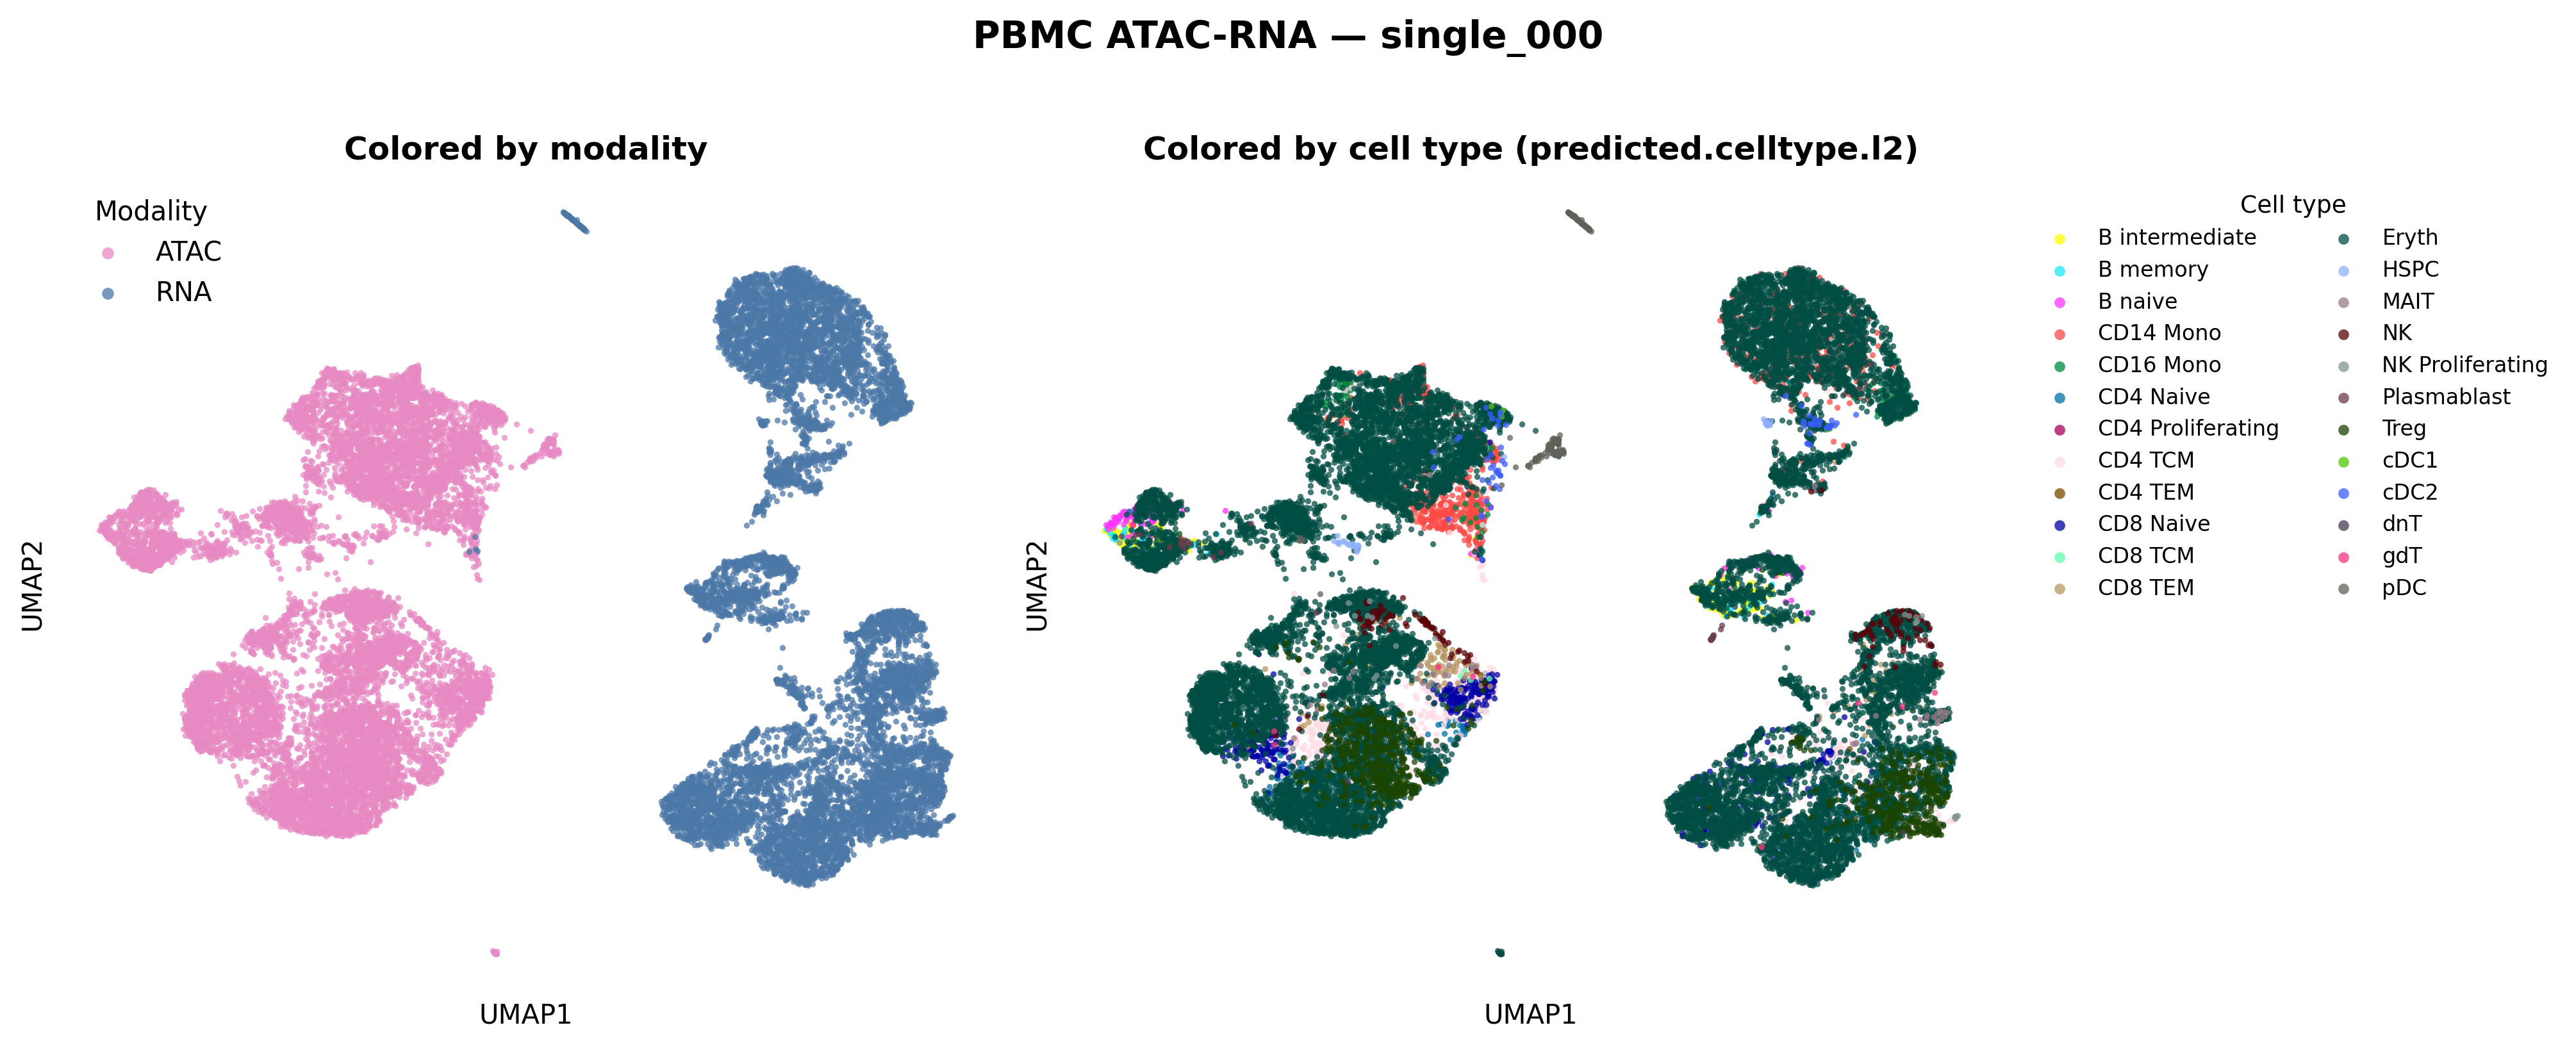

Saved: /data5/zhangye/scMRDR/output/PBMC/scMRDR_results/figures/alignment_umap/aligned_umap_single_000_predicted_celltype_l2_coordinates.csv


In [7]:
SELECTED_EXPERIMENT = "PBMC ATAC-RNA"
PBMC_CELLTYPE_KEY = "predicted.celltype.l2"

available_ratios = discover_ratios(
    EXPERIMENTS[SELECTED_EXPERIMENT]["out_root"]
)

print("Available ratios:", available_ratios)

if available_ratios:
    # Change this if you want a specific ratio, e.g. "single_020".
    SELECTED_RATIO = available_ratios[0]

    plot_adata, celltype_key = load_aligned_embedding(
        SELECTED_EXPERIMENT,
        SELECTED_RATIO,
        max_cells=MAX_CELLS,
        celltype_key=PBMC_CELLTYPE_KEY,
    )

    print("Cell-type key:", celltype_key)

    adata_umap = compute_umap(
        plot_adata,
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        random_state=RANDOM_STATE,
    )

    figure_dir = (
        EXPERIMENTS[SELECTED_EXPERIMENT]["out_root"]
        / "figures"
        / "alignment_umap"
    )

    plot_alignment_pair(
        adata_umap,
        save_dir=figure_dir,
        file_prefix=(
            f"aligned_umap_{SELECTED_RATIO}_"
            f"{PBMC_CELLTYPE_KEY.replace('.', '_')}"
        ),
    )

    save_umap_coordinates(
        adata_umap,
        figure_dir
        / (
            f"aligned_umap_{SELECTED_RATIO}_"
            f"{PBMC_CELLTYPE_KEY.replace('.', '_')}_coordinates.csv"
        ),
    )
else:
    print(
        "No completed ratio folders were found. "
        "Check PROJECT_ROOT and run model training first."
    )


## 8. Interactive explorer

For PBMC, the **Cell type** dropdown lets you switch between Azimuth L1, L2 and L3.

For datasets without an external annotation configuration, `Auto` searches existing `adata.obs` columns.


In [10]:
if HAS_WIDGETS:
    experiment_widget = widgets.Dropdown(
        options=list(EXPERIMENTS.keys()),
        value="PBMC ATAC-RNA",
        description="Experiment:",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="430px"),
    )

    ratio_widget = widgets.Dropdown(
        description="Ratio:",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="300px"),
    )

    celltype_widget = widgets.Dropdown(
        description="Cell type:",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="350px"),
    )

    neighbors_widget = widgets.IntSlider(
        value=N_NEIGHBORS,
        min=5,
        max=80,
        step=5,
        description="Neighbors:",
        continuous_update=False,
        style={"description_width": "90px"},
    )

    min_dist_widget = widgets.FloatSlider(
        value=MIN_DIST,
        min=0.0,
        max=0.95,
        step=0.05,
        description="Min dist:",
        continuous_update=False,
        style={"description_width": "90px"},
    )

    max_cells_widget = widgets.IntText(
        value=0 if MAX_CELLS is None else int(MAX_CELLS),
        description="Max cells:",
        style={"description_width": "90px"},
    )

    output_widget = widgets.Output()

    def refresh_ratio_options(*_):
        ratios = discover_ratios(
            EXPERIMENTS[experiment_widget.value]["out_root"]
        )
        ratio_widget.options = ratios

        if ratios:
            ratio_widget.value = ratios[0]

    def refresh_celltype_options(*_):
        cfg = EXPERIMENTS[experiment_widget.value]
        external_columns = cfg.get("annotation_columns", [])

        options = [("Auto", None)]

        for key in external_columns:
            label = key

            if key == "predicted.celltype.l1":
                label = "Azimuth L1"
            elif key == "predicted.celltype.l2":
                label = "Azimuth L2"
            elif key == "predicted.celltype.l3":
                label = "Azimuth L3"

            options.append((label, key))

        celltype_widget.options = options

        default_key = cfg.get("default_celltype_key")
        option_values = [value for _, value in options]

        if default_key in option_values:
            celltype_widget.value = default_key
        else:
            celltype_widget.value = None

    def redraw(*_):
        with output_widget:
            clear_output(wait=True)

            if ratio_widget.value is None:
                print(
                    "No completed ratio folders found for this experiment."
                )
                return

            max_cells_value = (
                None
                if max_cells_widget.value <= 0
                else max_cells_widget.value
            )

            try:
                plot_adata, resolved_key = load_aligned_embedding(
                    experiment_widget.value,
                    ratio_widget.value,
                    max_cells=max_cells_value,
                    celltype_key=celltype_widget.value,
                )

                print("Using cell-type key:", resolved_key)

                adata_umap = compute_umap(
                    plot_adata,
                    n_neighbors=neighbors_widget.value,
                    min_dist=min_dist_widget.value,
                    random_state=RANDOM_STATE,
                )

                plot_alignment_pair(
                    adata_umap,
                    save_dir=None,
                    point_size=POINT_SIZE,
                    alpha=POINT_ALPHA,
                )

            except Exception as exc:
                print(type(exc).__name__ + ":", exc)

    experiment_widget.observe(
        refresh_ratio_options,
        names="value",
    )
    experiment_widget.observe(
        refresh_celltype_options,
        names="value",
    )
    experiment_widget.observe(
        redraw,
        names="value",
    )
    ratio_widget.observe(
        redraw,
        names="value",
    )
    celltype_widget.observe(
        redraw,
        names="value",
    )
    neighbors_widget.observe(
        redraw,
        names="value",
    )
    min_dist_widget.observe(
        redraw,
        names="value",
    )
    max_cells_widget.observe(
        redraw,
        names="value",
    )

    refresh_ratio_options()
    refresh_celltype_options()

    controls = widgets.VBox(
        [
            experiment_widget,
            widgets.HBox(
                [
                    ratio_widget,
                    celltype_widget,
                ]
            ),
            widgets.HBox(
                [
                    neighbors_widget,
                    min_dist_widget,
                    max_cells_widget,
                ]
            ),
        ]
    )

    display(controls, output_widget)
    redraw()

else:
    print(
        "Install ipywidgets to enable this section: "
        "pip install ipywidgets"
    )


Install ipywidgets to enable this section: pip install ipywidgets


## 9. Compare all ratios

For PBMC, pass the Azimuth label level explicitly so all ratios use the same biological annotation definition.

Examples:

```python
plot_all_ratios(
    "PBMC ATAC-RNA",
    celltype_key="predicted.celltype.l2",
)

plot_all_ratios(
    "PBMC ATAC-RNA",
    celltype_key="predicted.celltype.l1",
)
```


In [11]:
def plot_all_ratios(
    experiment_name: str,
    celltype_key: str | None = None,
    n_neighbors: int = N_NEIGHBORS,
    min_dist: float = MIN_DIST,
    max_cells: int | None = MAX_CELLS,
    n_cols: int = 3,
    save: bool = True,
):
    ratios = discover_ratios(
        EXPERIMENTS[experiment_name]["out_root"]
    )

    if not ratios:
        raise RuntimeError(
            f"No completed ratios found for {experiment_name}"
        )

    records = []

    for ratio in ratios:
        print("Processing:", ratio)

        plot_adata, resolved_key = load_aligned_embedding(
            experiment_name,
            ratio,
            max_cells=max_cells,
            celltype_key=celltype_key,
        )

        adata_umap = compute_umap(
            plot_adata,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=RANDOM_STATE,
        )

        records.append(
            (
                ratio,
                adata_umap,
                resolved_key,
            )
        )

    # ========================================================
    # Figure 1: modality
    # ========================================================
    n_rows = math.ceil(len(records) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        squeeze=False,
        dpi=DPI,
    )

    for ax, (ratio, adata_umap, _) in zip(
        axes.ravel(),
        records,
    ):
        coords = adata_umap.obsm["X_umap"]

        labels = (
            adata_umap.obs["_modality_plot"]
            .astype(str)
            .to_numpy()
        )

        _scatter_categories(
            ax,
            coords,
            labels,
            MODALITY_PALETTE,
            POINT_SIZE,
            POINT_ALPHA,
        )

        _clean_axis(ax, ratio)

    for ax in axes.ravel()[len(records):]:
        ax.axis("off")

    modality_labels = sorted(
        {
            label
            for _, adata_umap, _ in records
            for label in (
                adata_umap.obs["_modality_plot"]
                .astype(str)
                .unique()
            )
        }
    )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=MODALITY_PALETTE.get(
                label,
                "#BDBDBD",
            ),
            markeredgecolor="none",
            label=label,
        )
        for label in modality_labels
    ]

    fig.legend(
        handles=handles,
        title="Modality",
        frameon=False,
        loc="center right",
    )

    fig.suptitle(
        f"{experiment_name}: aligned UMAP by modality",
        fontsize=14,
    )

    fig.tight_layout(
        rect=[0, 0, 0.93, 0.96]
    )

    save_dir = (
        EXPERIMENTS[experiment_name]["out_root"]
        / "figures"
        / "alignment_umap"
    )

    if save:
        save_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        png = (
            save_dir
            / "all_ratios_umap_by_modality.png"
        )
        pdf = (
            save_dir
            / "all_ratios_umap_by_modality.pdf"
        )

        fig.savefig(
            png,
            dpi=DPI,
            bbox_inches="tight",
        )
        fig.savefig(
            pdf,
            bbox_inches="tight",
        )

        print("Saved:", png)
        print("Saved:", pdf)

    plt.show()

    # ========================================================
    # Figure 2: cell type
    # ========================================================
    valid = [
        (r, a, k)
        for r, a, k in records
        if k is not None
        and "_celltype_plot" in a.obs
    ]

    if not valid:
        print(
            "No cell-type annotations were available. "
            "Modality UMAP was generated successfully."
        )
        return records

    all_celltypes = sorted(
        {
            label
            for _, adata_umap, _ in valid
            for label in (
                adata_umap.obs["_celltype_plot"]
                .astype(str)
                .unique()
            )
        }
    )

    celltype_palette = make_celltype_palette(
        all_celltypes
    )

    n_rows = math.ceil(
        len(valid) / n_cols
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        squeeze=False,
        dpi=DPI,
    )

    for ax, (ratio, adata_umap, _) in zip(
        axes.ravel(),
        valid,
    ):
        coords = adata_umap.obsm["X_umap"]

        labels = (
            adata_umap.obs["_celltype_plot"]
            .astype(str)
            .to_numpy()
        )

        _scatter_categories(
            ax,
            coords,
            labels,
            celltype_palette,
            POINT_SIZE,
            POINT_ALPHA,
        )

        _clean_axis(ax, ratio)

    for ax in axes.ravel()[len(valid):]:
        ax.axis("off")

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=celltype_palette[label],
            markeredgecolor="none",
            label=label,
        )
        for label in all_celltypes
    ]

    fig.legend(
        handles=handles,
        title="Cell type",
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(0.93, 0.5),
        ncol=1 if len(all_celltypes) <= 15 else 2,
    )

    resolved_name = valid[0][2]

    fig.suptitle(
        f"{experiment_name}: aligned UMAP by cell type "
        f"({resolved_name})",
        fontsize=14,
    )

    fig.tight_layout(
        rect=[0, 0, 0.88, 0.96]
    )

    if save:
        safe_key = (
            str(resolved_name)
            .replace(".", "_")
            .replace("/", "_")
        )

        png = (
            save_dir
            / f"all_ratios_umap_by_celltype_{safe_key}.png"
        )
        pdf = (
            save_dir
            / f"all_ratios_umap_by_celltype_{safe_key}.pdf"
        )

        fig.savefig(
            png,
            dpi=DPI,
            bbox_inches="tight",
        )
        fig.savefig(
            pdf,
            bbox_inches="tight",
        )

        print("Saved:", png)
        print("Saved:", pdf)

    plt.show()

    return records


# Recommended PBMC call:
# records = plot_all_ratios(
#     "PBMC ATAC-RNA",
#     celltype_key="predicted.celltype.l2",
# )


## 10. Interpretation

For an aligned multi-omics latent space:

- **Colored by modality:** RNA and ATAC should overlap substantially rather than form completely separate modality-specific clouds.
- **Colored by cell type:** biological identities should remain structured after alignment.

For PBMC, the right-hand plot is now based on the separately generated Azimuth labels rather than on `training_adata_post.h5ad` itself.

### Recommended PBMC annotation level

- **L1:** coarse classes; easiest to read, but some cells can be grouped broadly (for example `other`);
- **L2:** recommended default for figures; intermediate biological resolution;
- **L3:** most detailed; useful for inspection but can create a crowded legend.

The uploaded CSV contains 11,909 unique `cell_id` values and L1/L2/L3 annotations. The notebook reports the match rate each time a PBMC training output is loaded.


## 11. Recommended repository location

Keep this notebook at:

```text
notebooks/
└── visualization/
    └── aligned_umap.ipynb
```

The annotation CSV remains data input:

```text
input/
└── PBMC/
    └── raw_input/
        └── pbmc_azimuth_annotations.csv
```

A clean project structure is:

```text
scMRDR_RE/
├── README.md
├── src/
│   └── scMRDR/
├── scripts/
│   ├── PBMC_train/
│   └── BMMC_train/
├── notebooks/
│   └── visualization/
│       └── aligned_umap.ipynb
├── input/
│   └── PBMC/
│       └── raw_input/
│           └── pbmc_azimuth_annotations.csv
└── output/
```

Generated figures are saved under the corresponding model output:

```text
output/.../figures/alignment_umap/
```

This keeps **input annotations**, **training code**, **interactive visualization**, and **generated results** clearly separated.
